# HDT 2: Probabilidad, MLE y MAP

**Ciencia de Datos, Sección A** · Asignada: jueves 6 de agosto · **Entrega: jueves 13 de agosto, 23:59**

**Nombre:** Milton Beltran

Completar las celdas marcadas con `# ¿Qué va aquí?`. Cada ejercicio incluye una verificación comentada: descomentar para comprobar el resultado. Antes de entregar: **Kernel → Restart & Run All** (un notebook que no corre de arriba a abajo pierde 0.5 pts).

AI: resolver sin AI. Si se usó para entender un concepto, anotarlo en la mini-bitácora del final.

## Setup

Dependencias: `pip install numpy pandas matplotlib requests`. El rango de fechas es fijo (1 de mayo al 31 de julio de 2026): todos trabajan con los mismos 92 días y las verificaciones son exactas.

In [1]:
import json
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

AZUL, ROJO, GRIS, LINEA = "#3A6EA5", "#B04A2E", "#75808E", "#E0E4EA"

def eje_limpio(ax):
    ax.grid(color=LINEA, lw=0.6, alpha=0.7)
    ax.spines[["top", "right"]].set_visible(False)

URL = "https://archive-api.open-meteo.com/v1/archive"

## Parte A · Adquirir los datos (0.6 pt)

Clima observado de Ciudad de Guatemala (14.63, -90.51), del **2026-05-01** al **2026-07-31**, con las variables diarias `temperature_2m_max` y `precipitation_sum`, zona horaria `America/Guatemala`.

### Ejercicio 1 (0.15): descargar de la API

Armar el diccionario `params` con latitud, longitud, fechas, variables diarias (las dos en una sola cadena separada por coma) y zona horaria. Hacer el request y validar.

In [2]:
params = {
    "latitude": 14.63,
    "longitude": -90.51,
    "start_date": "2026-05-01",
    "end_date": "2026-07-31",
    "daily": "temperature_2m_max,precipitation_sum",
    "timezone": "America/Guatemala",
}

r = requests.get(URL, params=params, timeout=20)
print(r.status_code)
datos = r.json()

# Verificación (descomentar):
assert r.status_code == 200
assert list(datos["daily"].keys()) == ["time", "temperature_2m_max", "precipitation_sum"]

200


### Ejercicio 2 (0.15): JSON a DataFrame

Crear `clima` a partir de `datos["daily"]` y convertir la columna `time` a datetime.

In [3]:
clima = pd.DataFrame(datos["daily"])

# convertir time a datetime
clima["time"] = pd.to_datetime(clima["time"])

# Verificación (descomentar):
assert clima.shape == (92, 3)
assert clima.isna().sum().sum() == 0
assert str(clima["time"].dtype).startswith("datetime")

clima.head()

,time,temperature_2m_max,precipitation_sum
0,2026-05-01,29.6,0.0
1,2026-05-02,31.1,0.2
2,2026-05-03,28.2,0.9
3,2026-05-04,28.6,0.8
4,2026-05-05,30.9,1.6


### Ejercicio 3 (0.15): días con lluvia

(a) Columna booleana `llovio`: lluvia **mayor a 1.0 mm** (estricto). (b) `k` = días con lluvia y `n` = total de días. (c) El día con la lluvia máxima: fecha y milímetros.

In [4]:
# a) columna booleana: True si la lluvia del dia pasa de 1.0 mm
clima["llovio"] = clima["precipitation_sum"] > 1.0

# b) k = dias con lluvia, n = total de dias
k = int(clima["llovio"].sum())
n = len(clima)

# c) el dia mas lluvioso
dia_max = clima.loc[clima["precipitation_sum"].idxmax()]

print("De", n, "dias llovio en", k, "( proporcion:", round(k / n, 3), ")")
print("------------------------------------------------------------------------------------")
print("El dia con mas lluvia fue el", dia_max["time"].date(), "con", dia_max["precipitation_sum"], "mm")

# Verificación (descomentar):
assert int(clima["llovio"].sum()) == 51 and len(clima) == 92

De 92 dias llovio en 51 ( proporcion: 0.554 )
------------------------------------------------------------------------------------
El dia con mas lluvia fue el 2026-06-22 con 27.7 mm


### Ejercicio 4 (0.15): ficha de procedencia

Construir el diccionario `ficha` con las llaves `fuente`, `url`, `rango_fechas`, `fecha_descarga`, `filas` y `variables`. Guardarlo como `clima_procedencia.json` y guardar `clima` como `clima_gt.csv`.

In [5]:
from datetime import date

ficha = {
    "fuente": "Open-Meteo (archive API)",
    "url": URL,
    "rango_fechas": [params["start_date"], params["end_date"]],
    "fecha_descarga": date.today().isoformat(),
    "filas": len(clima),
    "variables": params["daily"].split(","),
}

# guardar ficha como clima_procedencia.json y clima como clima_gt.csv
with open("clima_procedencia.json", "w", encoding="utf-8") as f:
    json.dump(ficha, f, indent=2, ensure_ascii=False)

clima.to_csv("clima_gt.csv", index=False)

print(ficha)

# Verificación (descomentar):
import os
assert os.path.exists("clima_procedencia.json") and os.path.exists("clima_gt.csv")
assert ficha["filas"] == 92

{'fuente': 'Open-Meteo (archive API)', 'url': 'https://archive-api.open-meteo.com/v1/archive', 'rango_fechas': ['2026-05-01', '2026-07-31'], 'fecha_descarga': '2026-08-27', 'filas': 92, 'variables': ['temperature_2m_max', 'precipitation_sum']}


## Parte B · Estimar (1.2 pt)

Los datos ya están en memoria. Ahora la pregunta de la sesión 5: ¿qué parámetros hacen estos datos más plausibles?

### Ejercicio 5 (0.20): MLE de Bernoulli

Cada día es un ensayo Bernoulli: llueve o no. (a) `p_hat`, el MLE en una línea. (b) La función `log_lik` (vectorizada sobre `p`). (c) `p_grilla`: el argmax de `log_lik` sobre la grilla. Deben coincidir.

In [6]:
p_hat = k / n   # el MLE de Bernoulli es la proporcion de exitos

def log_lik(p, k, n):
    # log de p^k * (1-p)^(n-k); k y n son escalares, asi que queda vectorizada sobre p
    return k * np.log(p) + (n - k) * np.log(1 - p)

grilla = np.linspace(0.001, 0.999, 999)
p_grilla = grilla[np.argmax(log_lik(grilla, k, n))]

print("p_hat   =", round(p_hat, 4))
print("p_grilla =", round(p_grilla, 4))

# Verificación (descomentar):
assert abs(p_hat - k / n) < 1e-12
assert abs(p_grilla - p_hat) < 0.001

p_hat   = 0.5543
p_grilla = 0.554


### Ejercicio 6 (0.20): graficar la log-verosimilitud

Graficar `log_lik` sobre la grilla y marcar el máximo (línea vertical o anotación). El patrón está en el notebook de la sesión 5.

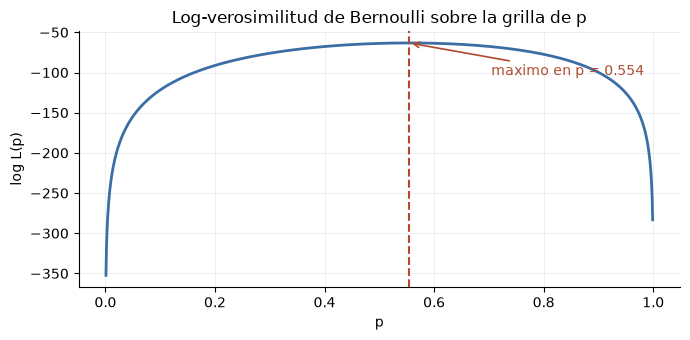

In [7]:
valores = log_lik(grilla, k, n)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(grilla, valores, color=AZUL, lw=2)
ax.axvline(p_hat, color=ROJO, ls="--", lw=1.5)
ax.annotate("maximo en p = " + str(round(p_hat, 3)),
            xy=(p_hat, valores.max()),
            xytext=(p_hat + 0.15, valores.max() - 40),
            color=ROJO,
            arrowprops=dict(arrowstyle="->", color=ROJO, lw=1.2))
ax.set_title("Log-verosimilitud de Bernoulli sobre la grilla de p")
ax.set_xlabel("p")
ax.set_ylabel("log L(p)")
eje_limpio(ax)
plt.tight_layout()
plt.show()

### Ejercicio 7 (0.20): MLE de la Normal

Sobre `temperature_2m_max`: (a) `mu_hat` sin usar `.mean()`. (b) `sigma2_hat`, el promedio de las desviaciones al cuadrado. Comparar con NumPy.

In [8]:
temp = clima["temperature_2m_max"]

# a) mu_hat: el promedio, sin usar .mean()
mu_hat = temp.sum() / len(temp)

# b) sigma2_hat: promedio de (temp - mu_hat)**2
sigma2_hat = ((temp - mu_hat) ** 2).sum() / len(temp)

print("mu_hat     =", round(mu_hat, 4), "| numpy:", round(temp.mean(), 4))
print("sigma2_hat =", round(sigma2_hat, 4))
print("sigma_hat  =", round(np.sqrt(sigma2_hat), 4), "| numpy:", round(temp.std(ddof=0), 4))

# Verificación (descomentar):
assert np.isclose(mu_hat, temp.mean())
assert np.isclose(np.sqrt(sigma2_hat), temp.std(ddof=0))

mu_hat     = 26.8598 | numpy: 26.8598
sigma2_hat = 3.6257
sigma_hat  = 1.9041 | numpy: 1.9041


### Ejercicio 8 (0.20): MAP con un prior equivocado

Prior Beta(2, 10): la creencia de alguien que piensa que en Guatemala casi no llueve (1 día de lluvia en 10 imaginarios). Implementar `map_beta` y comparar con el MLE usando los 92 días.

$$\hat{p}_{MAP} = \frac{k + \alpha - 1}{n + \alpha + \beta - 2}$$

In [9]:
def mle(k_, n_):
    return k_ / n_

def map_beta(k, n, a=2, b=10):
    return (k + a - 1) / (n + a + b - 2)

# comparar MLE y MAP con los 92 días
print("Con los", n, "dias: MLE =", round(mle(k, n), 3), "| MAP =", round(map_beta(k, n), 3),
      "| diferencia =", round(abs(mle(k, n) - map_beta(k, n)), 3))

# Verificación (descomentar):
assert round(map_beta(k, n), 3) == 0.510

Con los 92 dias: MLE = 0.554 | MAP = 0.51 | diferencia = 0.045


### Ejercicio 9 (0.20): el prior se diluye

Para cada `m` en `[7, 14, 30, 60, 92]`: con los **primeros** `m` días, calcular `k_m`, el MLE, el MAP y la diferencia absoluta. Guardar `(m, mle_m, map_m)` en `resultados` e imprimir la tabla.

In [10]:
ns = [7, 14, 30, 60, 92]
resultados = []

for m in ns:
    k_m = int(clima["llovio"][:m].sum())
    mle_m = mle(k_m, m)
    map_m = map_beta(k_m, m)
    resultados.append((m, mle_m, map_m))
    print("m =", m, "| k_m =", k_m, "| MLE =", round(mle_m, 3), "| MAP =", round(map_m, 3),
          "| |dif| =", round(abs(mle_m - map_m), 3))

# Verificación (descomentar):
difs = [abs(mle_m - map_m) for _, mle_m, map_m in resultados]
assert round(difs[0], 2) == 0.19 and round(difs[-1], 2) == 0.04

m = 7 | k_m = 3 | MLE = 0.429 | MAP = 0.235 | |dif| = 0.193
m = 14 | k_m = 4 | MLE = 0.286 | MAP = 0.208 | |dif| = 0.077
m = 30 | k_m = 14 | MLE = 0.467 | MAP = 0.375 | |dif| = 0.092
m = 60 | k_m = 38 | MLE = 0.633 | MAP = 0.557 | |dif| = 0.076
m = 92 | k_m = 51 | MLE = 0.554 | MAP = 0.51 | |dif| = 0.045


### Ejercicio 10 (0.20): graficar la dilución

Con `resultados`: graficar MLE y MAP contra `m` (dos series con leyenda). El patrón está en el notebook de la sesión 5.

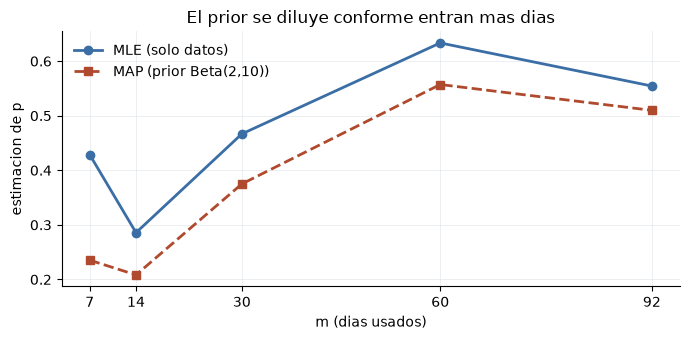

In [11]:
ms = [m for m, _, _ in resultados]
mles = [mle_m for _, mle_m, _ in resultados]
maps = [map_m for _, _, map_m in resultados]

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(ms, mles, color=AZUL, lw=2, marker="o", label="MLE (solo datos)")
ax.plot(ms, maps, color=ROJO, lw=2, ls="--", marker="s", label="MAP (prior Beta(2,10))")
ax.set_title("El prior se diluye conforme entran mas dias")
ax.set_xlabel("m (dias usados)")
ax.set_ylabel("estimacion de p")
ax.set_xticks(ms)
ax.legend(frameon=False)
eje_limpio(ax)
plt.tight_layout()
plt.show()

## Parte C · Criterio (0.2 pt)

### Ejercicio 11 (0.20)

El prior Beta(2,10) era objetivamente malo para época lluviosa. En 3-4 líneas, **citando los números del ejercicio 9**: ¿qué hicieron los datos con ese prior, a partir de cuántos días dejó de dominar, y qué implica esto para usar regularización (ridge/lasso) en modelos con pocos datos?



**Respuesta:** Los datos fueron borrando el prior poco a poco. Con m = 7 el MAP daba 0.235 contra un MLE de 0.429, es decir que los 10 días imaginarios del Beta(2,10) pesaban más que los 7 días reales; ya con m = 30 la diferencia baja a 0.09 (0.375 vs 0.467) y con los 92 días queda en 0.045 (0.510 vs 0.554), que es donde el prior prácticamente deja de importar. En la práctica dejó de dominar alrededor de los 30 días, que es cuando la muestra real ya triplica el peso del prior. 

## Mini-bitácora de AI (opcional, no penaliza)

Si se usó AI para entender algún concepto, anotar aquí qué se preguntó y qué se entendió. Si no se usó, escribir "No se usó".

- ...